# XGBoost – klasifikácia dát

Cieľom tejto práce je navrhnúť, implementovať a vyhodnotiť klasifikačný model založený na algoritme **XGBoost**.

---

## Dataset

V tejto práci používam **Breast Cancer Wisconsin Dataset**, ktorý je dostupný v knižnici `sklearn`.

Dataset obsahuje numerické charakteristiky buniek získané z obrazov tkaniva prsníka.
Každý riadok predstavuje jednu vzorku (pacienta) a každý stĺpec predstavuje určitú vlastnosť buniek (napr. veľkosť, tvar, textúra).

Cieľová premenná má dve hodnoty:
- **0 – malignant (malígny nádor)**
- **1 – benign (benígny nádor)**

Úlohou modelu je na základe vstupných príznakov správne klasifikovať typ nádoru.


## 1. Teoretický úvod

### Čo je XGBoost?
**XGBoost** (*Extreme Gradient Boosting*) je pokročilá implementácia algoritmu gradientného boostingu. Patrí medzi **ansámblové metódy**, čo znamená, že kombinuje viacero jednoduchších modelov (najčastejšie rozhodovacích stromov) do jedného silného a presného celku.

### Princíp aditívneho učenia
Model sa nevytvára naraz, ale buduje sa postupne v jednotlivých krokoch.
V každej iterácii sa pridáva nový strom \(h_m(x)\), ktorý sa snaží opraviť chyby aktuálneho modelu.

Tento proces môžeme zapísať ako:

$$
F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)
$$

kde:
- $F_{m-1}(x)$ je model z predchádzajúceho kroku,
- $h_m(x)$ je nový strom, ktorý sa učí na základe gradientov a hessiánov funkcie straty s cieľom minimalizovať chybu modelu,
- $\eta$ (*learning rate*) určuje, aký veľký vplyv má nový strom na výsledok a pomáha predchádzať preučeniu.

### Učenie na váhovaných príkladoch
XGBoost sa viac sústredí na prípady, kde model robí chyby.
Na rozdiel od jednoduchého boostingu sa tieto chyby vyjadrujú pomocou derivácií funkcie straty:

- **gradient (\(g_i\))** – určuje smer a veľkosť zmeny straty,
- **hessián (\(h_i\))** – vyjadruje zakrivenie funkcie straty a informuje o tom, ako rýchlo sa chyba mení.

Na základe týchto hodnôt sa optimalizujú rozdelenia stromu aj hodnoty v listoch.
Model sa tak v každej iterácii viac sústredí na chyby aktuálneho modelu.

### Intuitívne vysvetlenie
Model funguje v cykle:
1. Najprv urobí základný odhad.
2. Zistí, kde sa mýlil.
3. V ďalšom kroku pridá strom, ktorý sa snaží tieto chyby opraviť.
Opakovaním tohto procesu sa model postupne zlepšuje.

### Prečo sa XGBoost používa?
- **vysoká presnosť** – patrí medzi najlepšie algoritmy pre tabuľkové dáta,
- **efektivita** – využíva pokročilé optimalizačné techniky,
- **robustnosť** – dokáže zachytiť aj zložitejšie nelineárne vzťahy v dátach.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

from xgboost import XGBClassifier

## 2. Prieskum dát (EDA)

Pred vytvorením modelu je potrebné pozrieť sa na základné vlastnosti datasetu.
V tejto časti overím:
- rozmery dát,
- názvy a typy príznakov,
- prítomnosť chýbajúcich hodnôt,
- rozdelenie cieľovej premennej.

Tento krok je dôležitý, pretože pomáha lepšie pochopiť charakter dát ešte pred samotným trénovaním modelu.

In [4]:
# Načítanie datasetu
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")


In [5]:

# Základné informácie o dátach
print("Počet riadkov:", X.shape[0])
print("Počet príznakov:", X.shape[1])
print("Triedy:", data.target_names)


Počet riadkov: 569
Počet príznakov: 30
Triedy: ['malignant' 'benign']


In [6]:
print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [7]:
# Kontrola dátových typov a chýbajúcich hodnôt
print(X.info())


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [8]:
print("Počet chýbajúcich hodnôt v jednotlivých stĺpcoch:")
print(X.isnull().sum())

Počet chýbajúcich hodnôt v jednotlivých stĺpcoch:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [9]:
print("Počet tried:")
print(y.value_counts())
print()
print("Podiel tried:")
print(y.value_counts(normalize=True))

Počet tried:
target
1    357
0    212
Name: count, dtype: int64

Podiel tried:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


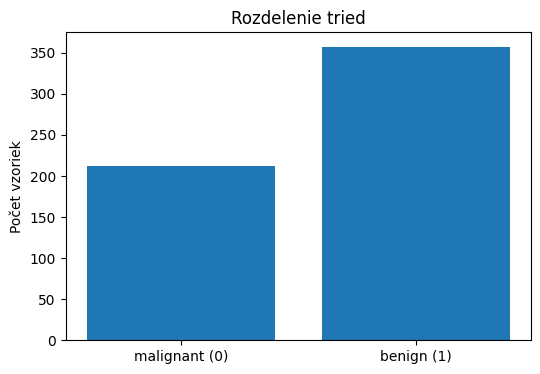

In [10]:
class_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_counts.values)
plt.title("Rozdelenie tried")
plt.ylabel("Počet vzoriek")
plt.show()

### Zhrnutie EDA
Zo základného prieskumu dát vidno, že dataset obsahuje iba numerické príznaky a neobsahuje chýbajúce hodnoty.
To znamená, že nie je potrebné vykonávať zložité predspracovanie.

Zároveň je možné vidieť rozdelenie cieľovej premennej, čo je dôležité pri hodnotení klasifikačného modelu.

## 3. Rozdelenie dát na trénovaciu a testovaciu množinu
Dataset rozdelíme na:
- **80 % trénovacích dát na učenie modelu**,
- **20 % testovacích dát na jeho vyhodnotenie**.

Použijeme parameter `stratify=y`, aby sa zachoval približne rovnaký pomer tried v oboch častiach.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## 4. Vyhodnocovacie metriky

Na posúdenie kvality modelu použijem viacero metrík:

- **accuracy** – podiel správnych predikcií,
- **precision** – podiel správne predikovaných pozitívnych prípadov,
- **recall** – podiel skutočných pozitívnych prípadov, ktoré model zachytil,
- **F1-score** – harmonický priemer precision a recall,
- **ROC-AUC** – miera schopnosti modelu rozlišovať medzi triedami.

Použitie viacerých metrík je dôležité, pretože samotná accuracy nemusí vždy poskytovať úplný obraz o kvalite modelu.

In [12]:
def evaluate_model(y_true, y_pred, y_proba=None, title="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"=== {title} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC  : {auc:.4f}")

    print()
    print(classification_report(y_true, y_pred, target_names=data.target_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax)
    plt.title(f"Confusion matrix – {title}")
    plt.show()

## 5. Variant A – XGBoost z knižnice s výberom parametrov

V tejto časti použijem hotovú implementáciu algoritmu `XGBClassifier`.
Namiesto ručného nastavenia parametrov využijem `GridSearchCV`, ktorý otestuje viacero kombinácií hyperparametrov a vyberie najlepší model.

Takýto prístup je vhodný, pretože umožňuje objektívnejšie nájsť nastavenie modelu s najlepším výkonom.

In [13]:
# základný model
xgb_model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

# mriežka parametrov
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_xgb_model = grid_search.best_estimator_

print("Najlepšie parametre:")
print(grid_search.best_params_)

print("\nNajlepší CV score:")
print(grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Najlepšie parametre:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.8}

Najlepší CV score:
0.9929824561403509


In [14]:
pred_xgb = best_xgb_model.predict(X_test)
pred_xgb_proba = best_xgb_model.predict_proba(X_test)[:, 1]

=== XGBoost z knižnice ===
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1-score : 0.9660
ROC-AUC  : 0.9964

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



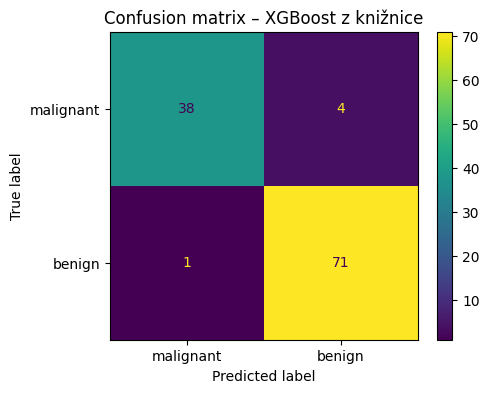

In [15]:
evaluate_model(
    y_test,
    pred_xgb,
    y_proba=pred_xgb_proba,
    title="XGBoost z knižnice"
)

### ROC krivka
ROC krivka zobrazuje schopnosť modelu rozlišovať medzi triedami pri rôznych rozhodovacích prahoch.
Čím bližšie je krivka k ľavému hornému rohu, tým lepší je model.

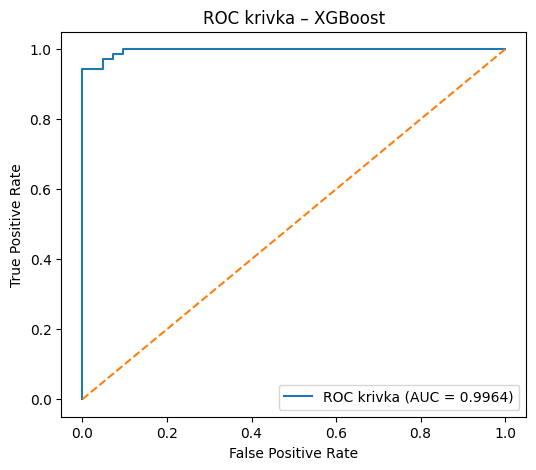

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, pred_xgb_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC krivka (AUC = {roc_auc_score(y_test, pred_xgb_proba):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivka – XGBoost")
plt.legend()
plt.show()

### Dôležitosť príznakov
Jednou z výhod algoritmu XGBoost je možnosť určiť, ktoré príznaky mali najväčší vplyv na rozhodovanie modelu

In [17]:
importances = best_xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
20,worst radius,0.281046
27,worst concave points,0.180060
7,mean concave points,0.117820
23,worst area,0.088233
22,worst perimeter,0.076286
11,texture error,0.042027
3,mean area,0.026277
1,mean texture,0.019319
26,worst concavity,0.017528
9,mean fractal dimension,0.017023


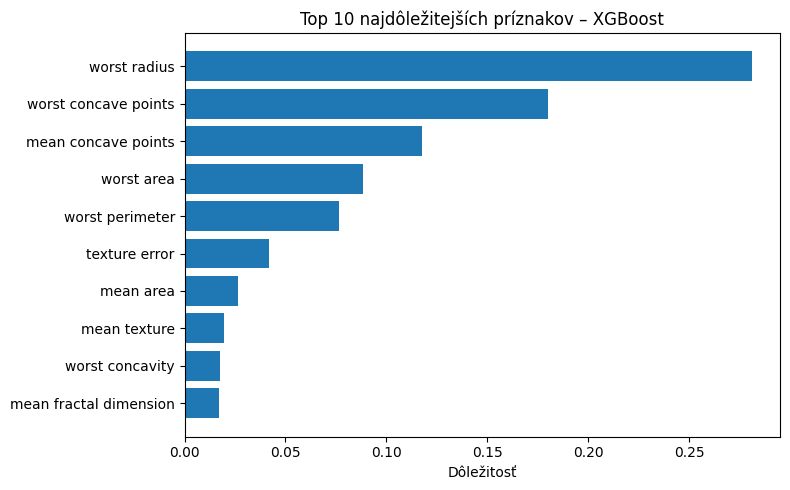

In [18]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"].head(10)[::-1],
    importance_df["importance"].head(10)[::-1]
)
plt.title("Top 10 najdôležitejších príznakov – XGBoost")
plt.xlabel("Dôležitosť")
plt.tight_layout()
plt.show()

## 6. Variant B – vlastná zjednodušená implementácia

V tejto časti implementujem zjednodušenú verziu algoritmu, ktorá vychádza priamo z matematických princípov XGBoost.
Na rozdiel od bežného gradientného boostingu, táto implementácia využíva:
- Gradienty ($g$) a Hessiány ($h$) pre logistickú funkciu straty.
- L2 regularizáciu ($\lambda$), ktorá zabraňuje príliš veľkým váham v listoch.
- Gain (zisk) ako kritérium pre hľadanie najlepšieho rozdelenia (namiesto MSE).


Ide o zjednodušenú implementáciu inšpirovanú algoritmom XGBoost. Zachováva jeho základné princípy, teda využitie gradientov, hessiánov, regularizácie a gain kritéria, ale neobsahuje všetky optimalizačné mechanizmy originálnej knižnice XGBoost, ako napríklad pruning, subsampling, prácu s chýbajúcimi hodnotami či rast hlbších stromov.

### Sigmoid funkcia

Pri binárnej klasifikácii potrebujeme previesť skóre modelu na pravdepodobnosť.
Na to použijeme sigmoid funkciu:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Výsledok sigmoid funkcie je vždy v intervale od 0 do 1.

In [19]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

### Rozhodovací stump pre XGBoost

V XGBoost sa hodnota v liste (leaf weight) nepočíta ako jednoduchý priemer rezíduí, ale pomocou **gradientov** a **hessiánov**.
Optimálna váha listu $w$ (výstup modelu pre danú vetvu) je definovaná vzorcom:

$$w = -\frac{\sum g_i}{\sum h_i + \lambda}$$

Kde:
- $\sum g_i$ je súčet gradientov v danom liste.
- $\sum h_i$ je súčet hessiánov v danom liste.
- $\lambda$ je parameter **L2 regularizácie**, ktorý bráni príliš vysokým váham a preučeniu.



Kritérium pre výber najlepšieho rozdelenia (tzv. **Gain** alebo zisk) sa počíta nasledovne:

$$Gain = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right]$$

**Vysvetlenie zložiek:**
- $\frac{G_L^2}{H_L + \lambda}$: Skóre pre ľavú vetvu.
- $\frac{G_R^2}{H_R + \lambda}$: Skóre pre pravú vetvu.
- $\frac{(G_L + G_R)^2}{H_L + H_R + \lambda}$: Skóre, ak by k rozdeleniu nedošlo (pôvodný uzol).

Algoritmus prechádza všetky možné prahy rozdelenia a vyberie ten, ktorý maximalizuje tento **Gain**.

### Výpočet Gradientov a Hessiánov

Pre úlohu binárnej klasifikácie používame logistickú funkciu straty (Log Loss). Pre každú vzorku $i$ vypočítame:

1. **Gradient ($g_i$):** Prvá derivácia straty podľa predikcie.
   $$g_i = p_i - y_i$$
2. **Hessián ($h_i$):** Druhá derivácia straty podľa predikcie.
   $$h_i = p_i \cdot (1 - p_i)$$

Kde $p_i$ je aktuálna pravdepodobnosť vypočítaná sigmoid funkciou a $y_i$ je skutočná hodnota (0 alebo 1).

In [20]:
class XGBoostStump:
    def __init__(self, lambd=1.0):
        self.lambd = lambd
        self.feature_index = None
        self.threshold = None
        self.left_weight = None
        self.right_weight = None
        self.best_gain = -np.inf

    def fit(self, X, g, h):
        X = np.asarray(X)
        g = np.asarray(g)
        h = np.asarray(h)

        n_samples, n_features = X.shape
        best_gain = -np.inf

        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                G_L = g[left_mask].sum()
                H_L = h[left_mask].sum()
                G_R = g[right_mask].sum()
                H_R = h[right_mask].sum()

                gain = 0.5 * (
                    (G_L ** 2) / (H_L + self.lambd) +
                    (G_R ** 2) / (H_R + self.lambd) -
                    ((G_L + G_R) ** 2) / (H_L + H_R + self.lambd)
                )

                if gain > best_gain:
                    best_gain = gain
                    self.best_gain = gain
                    self.feature_index = feature_idx
                    self.threshold = threshold
                    self.left_weight = -G_L / (H_L + self.lambd)
                    self.right_weight = -G_R / (H_R + self.lambd)


        if self.feature_index is None:
            G = g.sum()
            H = h.sum()
            leaf_weight = -G / (H + self.lambd)

            self.feature_index = 0
            self.threshold = np.inf
            self.left_weight = leaf_weight
            self.right_weight = leaf_weight

        return self

    def predict(self, X):
        X = np.asarray(X)
        mask = X[:, self.feature_index] <= self.threshold
        return np.where(mask, self.left_weight, self.right_weight)

### Vlastný zjednodušený XGBoost klasifikátor

Model bude fungovať takto:
1. nastaví sa počiatočná predikcia,
2. vypočítajú sa aktuálne pravdepodobnosti,
3. určia sa gradienty $g_i = p_i - y_i$ a hessiany $h_i = p_i \cdot (1 - p_i)$,
4. nový stump sa učí na základe týchto hodnôt a vyberá rozdelenie maximalizujúce gain,
5. jeho výstup sa pripočíta k aktuálnemu modelu.

Týmto spôsobom sa model v každom kroku snaží opraviť predchádzajúce chyby.

In [21]:
class SimpleXGBClassifier:
    def __init__(self, n_estimators=30, learning_rate=0.1, lambd=1.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.lambd = lambd
        self.base_score = 0.0
        self.stumps = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        # počiatočný log-odds odhad
        p_mean = np.clip(np.mean(y), 1e-6, 1 - 1e-6)
        self.base_score = np.log(p_mean / (1 - p_mean))


        F = np.full(len(y), self.base_score)   #obsahuje aktuálnu predikciu modelu pre všetky vzorky.
        self.stumps = []


        for _ in range(self.n_estimators):
            prob = sigmoid(F)

            gradients = prob - y
            hessians = prob * (1 - prob)

            stump = XGBoostStump(lambd=self.lambd)
            stump.fit(X, gradients, hessians)

            update = stump.predict(X)
            F += self.learning_rate * update

            self.stumps.append(stump)

        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        F = np.full(X.shape[0], self.base_score)

        for stump in self.stumps:
            F += self.learning_rate * stump.predict(X)

        p1 = sigmoid(F)
        return np.column_stack([1 - p1, p1])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

In [22]:
# Inicializácia modelu s regularizáciou
simple_model = SimpleXGBClassifier(
    n_estimators=40,
    learning_rate=0.2,
    lambd=1.0
)


simple_model.fit(X_train.values, y_train.values)

# Predikcia
pred_simple = simple_model.predict(X_test.values)
pred_simple_proba = simple_model.predict_proba(X_test.values)[:, 1]


=== Vlastná zjednodušená implementácia princípu XGBoost ===
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1-score : 0.9660
ROC-AUC  : 0.9927

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



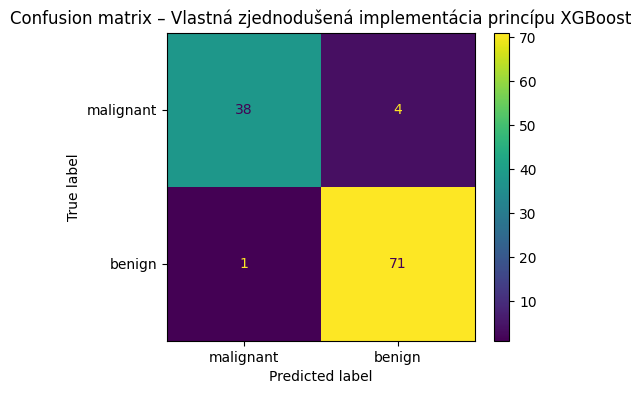

In [23]:
evaluate_model(
    y_test,
    pred_simple,
    y_proba=pred_simple_proba,
    title="Vlastná zjednodušená implementácia princípu XGBoost"
)

## 7. Porovnanie oboch prístupov

Na záver porovnám výsledky:
- optimalizovaného modelu XGBoost z knižnice
- vlastnej zjednodušenej implementácie princípu XGBoost.

In [24]:
acc_xgb = accuracy_score(y_test, pred_xgb)
prec_xgb = precision_score(y_test, pred_xgb)
rec_xgb = recall_score(y_test, pred_xgb)
f1_xgb = f1_score(y_test, pred_xgb)
auc_xgb = roc_auc_score(y_test, pred_xgb_proba)

acc_simple = accuracy_score(y_test, pred_simple)
prec_simple = precision_score(y_test, pred_simple)
rec_simple = recall_score(y_test, pred_simple)
f1_simple = f1_score(y_test, pred_simple)
auc_simple = roc_auc_score(y_test, pred_simple_proba)

comparison_df = pd.DataFrame({
    "Model": ["XGBoost knižnica", "Zjednodušený princíp XGBoost"],
    "Accuracy": [acc_xgb, acc_simple],
    "Precision": [prec_xgb, prec_simple],
    "Recall": [rec_xgb, rec_simple],
    "F1-score": [f1_xgb, f1_simple],
    "ROC-AUC": [auc_xgb, auc_simple]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost knižnica,0.95614,0.946667,0.986111,0.965986,0.996362
1,Zjednodušený princíp XGBoost,0.95614,0.946667,0.986111,0.965986,0.992725


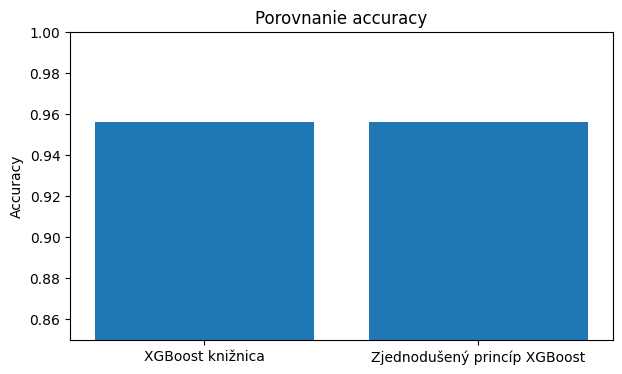

In [25]:
plt.figure(figsize=(7, 4))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Porovnanie accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.0)
plt.show()

## 8. Záver

V tejto práci bol navrhnutý a vyhodnotený klasifikačný model založený na algoritme XGBoost.

Najskôr bol vykonaný prieskum dát, následne bol natrénovaný model pomocou knižničnej implementácie s ladením hyperparametrov a bola vytvorená aj vlastná zjednodušená verzia algoritmu.

Výsledky ukázali, že:

- knižničná implementácia XGBoost dosahuje veľmi vysokú presnosť a výborné hodnoty všetkých metrík,
- vlastná implementácia dosahuje takmer identické výsledky v základných metrikách (accuracy, precision, recall a F1-score),
- rozdiel medzi modelmi sa prejavuje najmä v metrike ROC-AUC, čo poukazuje na mierne lepšiu diskriminačnú schopnosť knižničného modelu,
- boostingový prístup umožňuje postupné zlepšovanie modelu na základe chýb predchádzajúcich iterácií.

Na základe dosiahnutých výsledkov možno konštatovať, že algoritmus XGBoost je veľmi vhodný na klasifikáciu tabuľkových dát.

Zároveň sa ukázalo, že aj zjednodušená implementácia dokáže dosiahnuť porovnateľné výsledky, čo potvrdzuje robustnosť gradient boosting prístupu a jeho schopnosť efektívne modelovať komplexné vzťahy v dátach.

## 9. Uloženie modelu pre funkčnú aplikáciu

Aby bolo možné použiť natrénovaný model aj vo funkčnej aplikácii, uložím:
- model XGBoost vo formáte JSON,
- celý dataset do CSV,
- dôležitosť príznakov,
- mediány príznakov,
- zoznam názvov stĺpcov.

Tieto súbory budú následne načítané v aplikácii R Shiny bez potreby opätovného trénovania modelu.

In [28]:
import pandas as pd
import joblib
from pathlib import Path

# vytvorenie priečinka pre export
export_dir = Path("shiny_data")
export_dir.mkdir(exist_ok=True)

In [29]:
# 1. uloženie natrénovaného XGBoost modelu vo formáte JSON
best_xgb_model.get_booster().save_model(export_dir / "xgb_model.json")
# 2. uloženie celého datasetu
dataset_df = X.copy()
dataset_df["target"] = y.values
dataset_df.to_csv(export_dir / "dataset.csv", index=False)
# 3. uloženie feature importance
importance_df.to_csv(export_dir / "importance.csv", index=False)
# 4. uloženie mediánov príznakov
feature_medians = X.median()
feature_medians.to_csv(export_dir / "feature_medians.csv")
# 5. uloženie názvov príznakov
pd.DataFrame({"feature_name": X.columns}).to_csv(
    export_dir / "feature_names.csv",
    index=False
)
# 6. uloženie základných informácií o modeli a datasete
model_info = pd.DataFrame({
    "metric": ["n_samples", "n_features", "accuracy", "precision", "recall", "f1_score", "roc_auc"],
    "value": [
        X.shape[0],
        X.shape[1],
        accuracy_score(y_test, pred_xgb),
        precision_score(y_test, pred_xgb),
        recall_score(y_test, pred_xgb),
        f1_score(y_test, pred_xgb),
        roc_auc_score(y_test, pred_xgb_proba)
    ]
})

model_info.to_csv(export_dir / "model_info.csv", index=False)
print("Súbory pre Shiny aplikáciu boli uložené do priečinka:", export_dir.resolve())
print(list(export_dir.iterdir()))

Súbory pre Shiny aplikáciu boli uložené do priečinka: C:\Users\svetl\PycharmProjects\xgboost\shiny_data
[WindowsPath('shiny_data/dataset.csv'), WindowsPath('shiny_data/feature_medians.csv'), WindowsPath('shiny_data/feature_names.csv'), WindowsPath('shiny_data/importance.csv'), WindowsPath('shiny_data/model_info.csv'), WindowsPath('shiny_data/xgb_model.json')]
